In [1]:
import pandas as pd

import uproot
import awkward as ak
import numpy as np
import vector
import matplotlib.pyplot as plt

from iminuit import cost, Minuit
from numba_stats import norm, crystalball, bernstein

import os
import platform
import subprocess
from tqdm import tqdm

# Remove the limit on displayed columns
pd.set_option('display.max_columns', None)

## Real Experiment Samples

In [2]:
# IMPORTANT I storngly recommend you mannual place files under the dataset folder, u
# sing this code to download may be extremely slow

dataset_folder = "dataset"

# Create the dataset directory if it doesn't exist
if not os.path.exists(dataset_folder):
    os.makedirs(dataset_folder)

# Base URL for downloading files
base_url1 = "https://atlas-opendata.web.cern.ch/atlas-opendata/13TeV/GamGam/Data"

# List of file names
file_names = [
    "data15_periodD.root",
    "data15_periodE.root",
    "data15_periodF.root",
    "data15_periodG.root",
    "data15_periodH.root",
    "data15_periodJ.root",
    "data16_periodA.root",
    "data16_PeriodI.root",
    "data16_periodB.root",
    "data16_periodC.root",
    "data16_periodD.root",
    "data16_periodE.root",
    "data16_periodF.root",
    "data16_periodG.root",
    "data16_periodK.root",
    "data16_periodL.root"
]

# Detect the current operating system
current_os = platform.system()
print("Detected OS:", current_os)

def download_file(fname, base_url):
    dest = os.path.join(dataset_folder, fname)
    url = f"{base_url}/{fname}"
    print(f"Downloading {fname} from {url} to {dest} ...")
    try:
        if current_os == "Windows":
            try:
                subprocess.run(["wget", "-O", dest, url], check=True)
            except Exception as e:
                print("wget failed, trying curl")
                subprocess.run(["curl", "-L", "-o", dest, url], check=True)
        elif current_os == "Darwin":  # macOS
            subprocess.run(["curl", "-L", "-o", dest, url], check=True)
        elif current_os == "Linux":
            try:
                subprocess.run(["wget", "-O", dest, url], check=True)
            except Exception as e:
                print("wget failed, trying curl")
                subprocess.run(["curl", "-L", "-o", dest, url], check=True)
        else:
            print("Unsupported system. Please download manually:", url)
    except Exception as e:
        print(f"Download of {fname} failed:", e)

# Check for each file; if missing, download it
for fname in file_names:
    file_path = os.path.join(dataset_folder, fname)
    if not os.path.exists(file_path):
        download_file(fname,base_url1)
    else:
        print(f"{fname} already exists, skipping download.")

# Construct the full list of file paths
file_list = [os.path.join(dataset_folder, fname) for fname in file_names]

Detected OS: Windows
data15_periodD.root already exists, skipping download.
data15_periodE.root already exists, skipping download.
data15_periodF.root already exists, skipping download.
data15_periodG.root already exists, skipping download.
data15_periodH.root already exists, skipping download.
data15_periodJ.root already exists, skipping download.
data16_periodA.root already exists, skipping download.
data16_PeriodI.root already exists, skipping download.
data16_periodB.root already exists, skipping download.
data16_periodC.root already exists, skipping download.
data16_periodD.root already exists, skipping download.
data16_periodE.root already exists, skipping download.
data16_periodF.root already exists, skipping download.
data16_periodG.root already exists, skipping download.
data16_periodK.root already exists, skipping download.
data16_periodL.root already exists, skipping download.


In [3]:
# List of branches to load
branches_to_load = [
    "photon_n",
    "photon_pt",
    "photon_eta",
    "photon_phi",
    "photon_e",
    "photon_isTightID",
    "photon_isTightIso"]

tree_name = "analysis"

df_ak = uproot.concatenate(
    [f"{fname}:{tree_name}" for fname in file_list],
    filter_name=branches_to_load,
    library="ak")

print("Successfully loaded data into an Awkward Array!")
print(df_ak)

df = ak.to_dataframe(df_ak)
print("Converted to pandas DataFrame with shape:", df.shape)

Successfully loaded data into an Awkward Array!
[{photon_n: 4, photon_pt: [84, 27.7, ..., 2.56], photon_eta: [...], ...}, ...]
Converted to pandas DataFrame with shape: (21881018, 7)


In [4]:
# List of branches to load
branches_to_load = [
    "photon_n",
    "photon_pt",
    "photon_eta",
    "photon_phi",
    "photon_e",
    "photon_isTightID",
    "photon_isTightIso"]

tree_name = "analysis"

df_ak = uproot.concatenate(
    [f"{fname}:{tree_name}" for fname in file_list],
    filter_name=branches_to_load,
    library="ak")

print("Successfully loaded data into an Awkward Array!")
print(df_ak)

df = ak.to_dataframe(df_ak)
print("Converted to pandas DataFrame with shape:", df.shape)

Successfully loaded data into an Awkward Array!
[{photon_n: 4, photon_pt: [84, 27.7, ..., 2.56], photon_eta: [...], ...}, ...]
Converted to pandas DataFrame with shape: (21881018, 7)


In [5]:
# photon_n: Number of photons detected in the event (dimensionless).
# photon_pt: Transverse momentum of the photon (unit: GeV).
# photon_eta: -ln[tan(theta/2)],  pseudorapidity of the photon, describing its direction relative to the beam axis. (dimensionless).
# photon_phi:  Azimuthal angle of the photon in the transverse plane, representing its angle around the beam axis (unit: radians).
# photon_e: Energy of the photon, which, with pt and eta, determines its kinematics (unit: GeV).
# photon_isTightID: Boolean flag indicating if the photon meets tight identification criteria, ensuring it is a genuine photon.
# photon_isTightIso: Boolean flag indicating if the photon satisfies tight isolation criteria, ensuring little contamination from nearby activity.

initial_entries = len(df.index.get_level_values("entry").unique())
print('number of events:',initial_entries)
df

number of events: 4998873


photon_n  photon_pt  photon_eta  photon_phi   photon_e  \
entry   subentry                                                           
0       0                4  84.029915   -0.379076    2.926059  90.140045   
        1                4  27.705812    0.822981   -0.087787  37.630032   
        2                4   9.295130    0.822584   -0.148857  12.621251   
        3                4   2.561815    0.495293    0.397490   2.882517   
1       0                3  26.147392    0.646658   -0.195641  31.807554   
...                    ...        ...         ...         ...        ...   
4998872 0                5  45.229176   -0.780109    1.077618  59.703987   
        1                5  24.633383   -0.776948    0.998972  32.449955   
        2                5   2.750755    0.034219    0.479718   2.752366   
        3                5   1.924721    0.327901    1.232729   2.029124   
        4                5   2.610134    1.165021    1.114317   4.591101   

                  photon_isTightID  photon_isTightIso  
entry   subentry                                       
0       0                     True               True  
        1                    False              False  
        2                    False              False  
        3                    False              False  
1       0                    False              False  
...                            ...                ...  
4998872 0                    False              False  
        1                    False              False  
        2                    False              False  
        3                    False              False  
        4                    False              False  

[21881018 rows x 7 columns]

In [6]:

# Remove subentries with photon_isTightID==False or photon_isTightIso==False.
# Keep only the photon subentries where both conditions are True.
df = df.query("photon_isTightID==True and photon_isTightIso==True")
print('number of events:',len(df.index.get_level_values("entry").unique()))
df


number of events: 1232427


photon_n   photon_pt  photon_eta  photon_phi    photon_e  \
entry   subentry                                                             
0       0                4   84.029915   -0.379076    2.926059   90.140045   
4       1                5   59.059853    0.768679    1.775464   77.384354   
8       0                5  175.072464    0.498776   -2.563042  197.304764   
13      1                2   25.951664   -0.857452    0.528262   36.090828   
20      0                3  169.535400    1.655890   -2.647090  460.175171   
...                    ...         ...         ...         ...         ...   
4998842 0                6  419.827393    0.717836    0.218997  532.718872   
        1                6   55.539581    2.080373   -0.944298  225.833252   
4998843 0                6   30.982269   -0.556572   -1.572960   35.906151   
4998856 0                5  156.887543   -1.833551    1.272712  503.288177   
4998868 0                6   30.079172   -2.268367    1.337810  146.892975   

                  photon_isTightID  photon_isTightIso  
entry   subentry                                       
0       0                     True               True  
4       1                     True               True  
8       0                     True               True  
13      1                     True               True  
20      0                     True               True  
...                            ...                ...  
4998842 0                     True               True  
        1                     True               True  
4998843 0                     True               True  
4998856 0                     True               True  
4998868 0                     True               True  

[1393216 rows x 7 columns]

In [7]:

# 2) Remove events with fewer than 2 remaining photons.
# Count the number of subentries per event (entry)
counts = df.groupby(level="entry").size()
# Keep only events with at least 2 subentries
valid_entries = counts[counts >= 2].index
df = df.loc[valid_entries]
print('number of events:',len(df.index.get_level_values("entry").unique()))
df

number of events: 159916


photon_n   photon_pt  photon_eta  photon_phi    photon_e  \
entry   subentry                                                             
28      0                2   24.301373   -0.551838    0.220681   28.096416   
        1                2   22.156801   -0.551341    0.220681   25.610559   
51      0                2   21.841619   -1.697066    0.019252   61.605740   
        1                2   28.870935   -0.097729   -2.882195   29.008919   
61      0                4   27.835691    2.175247   -2.111866  124.118530   
...                    ...         ...         ...         ...         ...   
4998752 1                3   22.588562    1.217327   -1.498527   41.497055   
4998804 0                4   57.539845    2.082422   -1.007647  234.431915   
        1                4   34.215073    1.639359    2.312095   91.456375   
4998842 0                6  419.827393    0.717836    0.218997  532.718872   
        1                6   55.539581    2.080373   -0.944298  225.833252   

                  photon_isTightID  photon_isTightIso  
entry   subentry                                       
28      0                     True               True  
        1                     True               True  
51      0                     True               True  
        1                     True               True  
61      0                     True               True  
...                            ...                ...  
4998752 1                     True               True  
4998804 0                     True               True  
        1                     True               True  
4998842 0                     True               True  
        1                     True               True  

[320705 rows x 7 columns]

<!-- 
def pick_best_pair_for_event(subdf):
    """
    Input: subdf is a DataFrame containing all photon (subentry) rows for a given event (entry).
    Output: (best_i, best_j, best_mass)
         where best_i and best_j are the subentry indices of the "optimal" photon pair in the event,
         and best_mass is their invariant mass.
         If no valid combination exists, returns None.

    Minimal modification: instead of choosing the pair whose mass is closest to 125 GeV,
    we now select the pair with the largest sum of photon pT.
    """
    
    # Extract the unique subentry indices for the event
    subentry_list = subdf.index.get_level_values("subentry").unique()

    best_pair = None
    best_sum_pt = -1.0  # track the maximum pT sum found so far

    for i, j in combinations(subentry_list, 2):
        # Retrieve the rows corresponding to subentries i and j
        row_i = subdf.xs(i, level="subentry")
        row_j = subdf.xs(j, level="subentry")

        pt_i  = row_i["photon_pt"].iloc[0]
        eta_i = row_i["photon_eta"].iloc[0]
        phi_i = row_i["photon_phi"].iloc[0]
        e_i   = row_i["photon_e"].iloc[0]

        pt_j  = row_j["photon_pt"].iloc[0]
        eta_j = row_j["photon_eta"].iloc[0]
        phi_j = row_j["photon_phi"].iloc[0]
        e_j   = row_j["photon_e"].iloc[0]

        # Construct the 4-vectors
        v1 = vector.obj(pt=pt_i, eta=eta_i, phi=phi_i, E=e_i)
        v2 = vector.obj(pt=pt_j, eta=eta_j, phi=phi_j, E=e_j)

        dipho_mass = (v1 + v2).m  # invariant mass

        # Instead of checking distance from 125 GeV, pick the pair with the highest sum of pT
        sum_pt = pt_i + pt_j
        if sum_pt > best_sum_pt:
            best_sum_pt = sum_pt
            best_pair = (i, j, dipho_mass)

    return best_pair  # Returns (best_i, best_j, best_mass) or None -->


In [8]:
# 3) For each event, generate all "two-photon combinations" and compute their invariant mass.

def pick_best_pair_for_event(subdf):
    """
    Input: subdf is a DataFrame containing all photon (subentry) rows for a given event (entry).
    Output: (best_i, best_j, best_mass)
         where best_i and best_j are the subentry indices of the "optimal" photon pair in the event,
         and best_mass is their invariant mass.
         If no valid combination exists, returns None.

    Minimal modification: instead of looping over all pairs, we now simply select the two photons with the highest pT.
    """
    # Sort the photons by pT in descending order
    sorted_df = subdf.sort_values("photon_pt", ascending=False)
    
    # Ensure there are at least two photons in the event
    if len(sorted_df) < 2:
        return None

    # Select the top two photons
    row1 = sorted_df.iloc[0]
    row2 = sorted_df.iloc[1]
    
    # Extract their subentry indices from the multi-index (entry, subentry)
    best_i = sorted_df.index[0][1]
    best_j = sorted_df.index[1][1]
    
    # Construct the 4-vectors
    v1 = vector.obj(pt=row1["photon_pt"], eta=row1["photon_eta"], phi=row1["photon_phi"], E=row1["photon_e"])
    v2 = vector.obj(pt=row2["photon_pt"], eta=row2["photon_eta"], phi=row2["photon_phi"], E=row2["photon_e"])
    
    # Compute the invariant mass of the two-photon system
    best_mass = (v1 + v2).m
    
    return (best_i, best_j, best_mass)

# 4# 4) Group by event and apply pick_best_pair_for_event to each event
pairs_info = df.groupby(level="entry", group_keys=False).apply(pick_best_pair_for_event)
# # pairs_info is a Series with index as entry; each value is (i, j, mass) or None

In [9]:
# 5) Mark the subentries to be kept based on the optimal photon pair (i, j)

valid_idx = []
for entry, triple in tqdm(pairs_info.items()):
    if triple is None:
        print('something is wrong------------------------------------------')
        # This indicates that there is no valid combination for the event 
        # (which should not happen because we ensured >=2 subentries)
        continue
    best_i, best_j, best_mass = triple
    # These two subentries constitute the "best photon pair"
    valid_idx.append((entry, best_i))
    valid_idx.append((entry, best_j))

# Convert to a set for fast membership checking
valid_idx = set(valid_idx)

159916it [00:00, 1176732.45it/s]


In [10]:
# Define a simple filter function
def keep_this_subentry(idx):
    """
    idx is a tuple (entry, subentry)
    Returns True/False indicating whether to keep this subentry.
    """
    return (idx in valid_idx)

# Create a new DataFrame that only retains the flagged subentries
df = df.loc[[i for i in df.index if keep_this_subentry(i)]]
print('number of events:',len(df.index.get_level_values("entry").unique()))

number of events: 159916


In [11]:


def compute_dipho_mass(group):
    """
    For an event (group containing two photons), construct two 4-vectors,
    then compute the invariant mass of the diphoton system.
    Assumes the group is already sorted by subentry (order does not affect mass calculation).
    """

    row1 = group.iloc[0]
    row2 = group.iloc[1]
    
    v1 = vector.obj(
        pt = row1["photon_pt"],
        eta = row1["photon_eta"],
        phi = row1["photon_phi"],
        E   = row1["photon_e"])
    
    v2 = vector.obj(
        pt = row2["photon_pt"],
        eta = row2["photon_eta"],
        phi = row2["photon_phi"],
        E   = row2["photon_e"])
    
    return (v1 + v2).m

# For each event (grouped by entry), compute the invariant mass
mass_series = df.groupby(level="entry").apply(compute_dipho_mass)
# mass_series index is the event number, and each value is the corresponding diphoton mass

# Add the computed invariant mass back to the original DataFrame;
# each subentry in an event gets the same diphoton mass.
df["diphoton_mass"] = df.index.get_level_values("entry").map(mass_series)

In [12]:
def check_pt(group):
    # Sort by photon_pt in descending order
    group_sorted = group.sort_values("photon_pt", ascending=False)
    # leading photon 和 subleading photon 的 pT
    pt_leading = group_sorted.iloc[0]["photon_pt"]
    pt_sub   = group_sorted.iloc[1]["photon_pt"]
    return (pt_leading > 50.0) and (pt_sub > 35.0)

# Find events that satisfy the pT conditions
pass_pt = df.groupby(level="entry").apply(check_pt)
valid_entries_pt = pass_pt[pass_pt].index
df = df.loc[valid_entries_pt]
df
print('number of events:',len(df.index.get_level_values("entry").unique()))

number of events: 65065


In [13]:
# Further require that for each event, both photons satisfy pT / diphoton_mass > 0.35
def check_ptom(group):
    # Since diphoton_mass is the same for all subentries in an event, 
    # group["photon_pt"]/group["diphoton_mass"] calculates the ratio for each subentry.
    return (group["photon_pt"] / group["diphoton_mass"] > 0.35).all()

pass_ptom = df.groupby(level="entry").apply(check_ptom)
valid_entries_ptom = pass_ptom[pass_ptom].index
df = df.loc[valid_entries_ptom]

print("After pT and pT/m cut, events:", df.index.get_level_values("entry").nunique())

After pT and pT/m cut, events: 38625


In [14]:
# Extract the diphoton_mass for each event
mass_series = df.groupby(level="entry")["diphoton_mass"].first()

# Keep only events with 100 ≤ mH ≤ 160 GeV
mass_series = mass_series[(mass_series >= 100) & (mass_series <= 160)]
print('number of events:',len(mass_series))

number of events: 9702


Number of events after all cuts: 9702


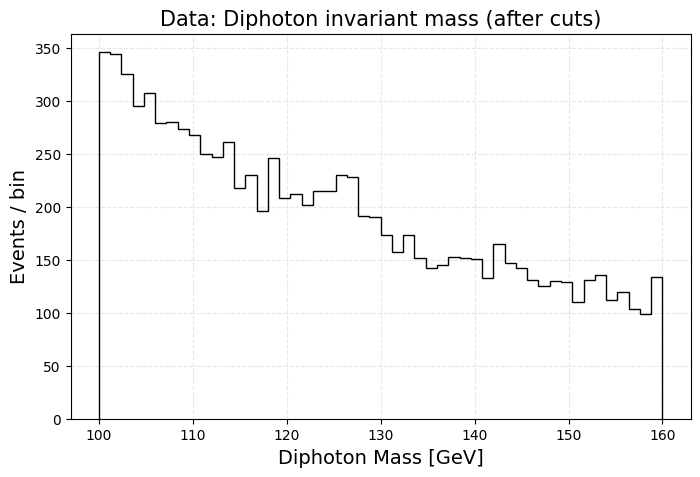

In [15]:
# Final diphoton invariant mass Series: mass_series
# Contains one mass value per event (in GeV) for all events passing the selection cuts.
print("Number of events after all cuts:", len(mass_series))

# convert to numpy series
mass_data = mass_series.values.astype(np.float64)

# check distribution again
plt.figure(figsize=(8,5))
plt.hist(mass_data, bins=50, range=(100,160), histtype='step', color='k')
plt.xlabel("Diphoton Mass [GeV]", fontsize=14)
plt.ylabel("Events / bin", fontsize=14)
plt.title("Data: Diphoton invariant mass (after cuts)", fontsize=15)
plt.grid(True, alpha=0.3, linestyle='--')
plt.show()

## Monte Carlo Samples

In [16]:
# IMPORTANT I storngly recommend you mannual place files under the dataset folder, u
# sing this code to download may be extremely slow

mc_file_list = [
    "mc_343981.ggH125_gamgam.GamGam.root",
    "mc_345041.VBFH125_gamgam.GamGam.root",
    "mc_345318.WpH125J_Wincl_gamgam.GamGam.root",
    "mc_345319.ZH125J_Zincl_gamgam.GamGam.root",
    "mc_341081.ttH125_gamgam.GamGam.root"]
mc_file_list = [f"dataset/{f}" for f in mc_file_list]

base_url2 = "https://atlas-opendata.web.cern.ch/atlas-opendata/samples/2020/GamGam/MC/"

# Use the previously defined download_file function to check/download each MC file
for fname in mc_file_list:
    if not os.path.exists(fname):
        download_file(os.path.basename(fname), base_url2)
    else:
        print(f"{os.path.basename(fname)} already exists, skipping download.")


mc_343981.ggH125_gamgam.GamGam.root already exists, skipping download.
mc_345041.VBFH125_gamgam.GamGam.root already exists, skipping download.
mc_345318.WpH125J_Wincl_gamgam.GamGam.root already exists, skipping download.
mc_345319.ZH125J_Zincl_gamgam.GamGam.root already exists, skipping download.
mc_341081.ttH125_gamgam.GamGam.root already exists, skipping download.


In [17]:
branches_mc = [
    "XSection",
    "mcWeight",
    "SumWeights",
    "photon_n",
    "photon_pt",
    "photon_eta",
    "photon_phi",
    "photon_E",
    "photon_isTightID",
    "photon_ptcone30",
    "photon_etcone20"]
tree_name_mc = "mini"

# 1) Load and merge all MC root files
mc_ak = uproot.concatenate(
    [f"{fname}:{tree_name_mc}" for fname in mc_file_list],
    filter_name=branches_mc,
    library="ak")

# 2) Convert to pandas DataFrame
mcdf = ak.to_dataframe(mc_ak)

def selection(df, query_string):
    evs_before = df.index.get_level_values('entry').nunique()
    df = df.query(query_string)
    evs_after = df.index.get_level_values('entry').nunique()
    eff = evs_after / evs_before
    return eff, df

# 3) Convert units from MeV -> GeV
mcdf["photon_pt"] = mcdf["photon_pt"] * 1e-3
mcdf["photon_E"]  = mcdf["photon_E"]  * 1e-3
mcdf["photon_ptcone30"] = mcdf["photon_ptcone30"] * 1e-3
mcdf["photon_etcone20"] = mcdf["photon_etcone20"] * 1e-3

mcdf

mcWeight  photon_n   photon_pt  photon_eta  photon_phi  \
entry   subentry                                                            
0       0         28.485731         2   58.376011   -0.482442    0.802856   
        1         28.485731         2   56.773354    0.190522   -2.473249   
1       0         28.485731         2   68.964722    1.911305   -0.928285   
        1         28.485731         2   66.471428    2.284927    3.092725   
2       0         28.485731         2   82.018768    1.024764   -2.291243   
...                     ...       ...         ...         ...         ...   
2473332 1          1.000000         2  111.542397   -1.763809    1.756902   
2473333 0          1.000000         2  139.347214   -1.003802    2.838935   
        1          1.000000         2  111.870224   -1.963647    2.703260   
2473334 0         -1.000000         2  182.607056    0.852567    1.145759   
        1         -1.000000         2  134.174377    1.256462    0.452155   

                    photon_E  photon_isTightID  photon_ptcone30  \
entry   subentry                                                  
0       0          65.302315              True         2.540679   
        1          57.806873              True         0.000000   
1       0         238.266098              True         0.000000   
        1         329.922729              True         0.000000   
2       0         128.987595              True         0.000000   
...                      ...               ...              ...   
2473332 1         334.962341              True         1.397086   
2473333 0         215.648087              True         0.000000   
        1         406.402649              True         0.000000   
2473334 0         253.091461              True         0.000000   
        1         254.772339              True         0.000000   

                  photon_etcone20  XSection  SumWeights  
entry   subentry                                         
0       0                1.820584  0.102000  55922616.0  
        1               -0.087104  0.102000  55922616.0  
1       0                1.520664  0.102000  55922616.0  
        1               -0.061093  0.102000  55922616.0  
2       0               -1.446894  0.102000  55922616.0  
...                           ...       ...         ...  
2473332 1               -0.621767  0.000003    485440.0  
2473333 0               -2.051400  0.000003    485440.0  
        1                0.356758  0.000003    485440.0  
2473334 0                0.974072  0.000003    485440.0  
        1                2.198523  0.000003    485440.0  

[4985936 rows x 11 columns]

In [18]:
# ========== Begin replicating the selection logic from the lecture notes ==========


#  Keep events with exactly 2 photons
eff, mcdf = selection(mcdf, "photon_n == 2")
print(f"keep events with exactly 2 photons, efficiency={eff:.3f}")

# Construct 4-vectors and store higgs_m in the DataFrame
photon1_p4 = vector.arr({
    'pt' : mcdf['photon_pt'][:,0],
    'eta': mcdf['photon_eta'][:,0],
    'phi': mcdf['photon_phi'][:,0],
    'E'  : mcdf['photon_E'][:,0]})

photon2_p4 = vector.arr({
    'pt' : mcdf['photon_pt'][:,1],
    'eta': mcdf['photon_eta'][:,1],
    'phi': mcdf['photon_phi'][:,1],
    'E'  : mcdf['photon_E'][:,1]})

higgs_p4 = photon1_p4 + photon2_p4

# Insert the same higgs_m value for subentry 0 and 1
mcdf.loc[(slice(None),0),'higgs_m'] = higgs_p4.m
mcdf.loc[(slice(None),1),'higgs_m'] = higgs_p4.m

# Keep events with invariant mass in the range 100 ~ 160 GeV
eff, mcdf = selection(mcdf, "(higgs_m >= 100) & (higgs_m <= 160)")
print(f"mass in [100,160] GeV, efficiency={eff:.3f}")

#  Photon pT cuts
passPT = ((mcdf["photon_pt"][:,0] > 50) &
    (mcdf["photon_pt"][:,1] > 35)) 
mcdf.loc[(slice(None),0),'photon_passPT'] = passPT.values
mcdf.loc[(slice(None),1),'photon_passPT'] = passPT.values

eff, mcdf = selection(mcdf, 'photon_passPT')
print(f"Photon PT efficiency={eff:.3f}")

#  photon ID
passID = (mcdf['photon_isTightID'][:,0]) & (mcdf['photon_isTightID'][:,1])
mcdf.loc[(slice(None),0),'photon_passID'] = passID.values
mcdf.loc[(slice(None),1),'photon_passID'] = passID.values

eff, mcdf = selection(mcdf, 'photon_passID')
print(f"Photon ID efficiency={eff:.3f}")

# Photon isolation cuts
#    The lecture notes use ptcone30 / pt < 0.065 and etcone20 / pt < 0.065.
passIso = (
    (mcdf['photon_ptcone30'][:,0] / mcdf['photon_pt'][:,0] < 0.065) &
    (mcdf['photon_ptcone30'][:,1] / mcdf['photon_pt'][:,1] < 0.065) &
    (abs(mcdf['photon_etcone20'][:,0]) / mcdf['photon_pt'][:,0] < 0.065) &
    (abs(mcdf['photon_etcone20'][:,1]) / mcdf['photon_pt'][:,1] < 0.065))
mcdf.loc[(slice(None),0),'passIso'] = passIso.values
mcdf.loc[(slice(None),1),'passIso'] = passIso.values

eff, mcdf = selection(mcdf, 'passIso')
print(f"Photon ISO efficiency={eff:.3f}")

# photon pT/m cuts
mcdf['photon_ptom'] = mcdf['photon_pt'] / mcdf['higgs_m']
passEnergyRatio = (
    (mcdf['photon_ptom'][:,0] > 0.35) &
    (mcdf['photon_ptom'][:,1] > 0.35))
mcdf.loc[(slice(None),0),'passEnergyRatio'] = passEnergyRatio.values
mcdf.loc[(slice(None),1),'passEnergyRatio'] = passEnergyRatio.values

eff, mcdf = selection(mcdf, 'passEnergyRatio')
print(f"Energy ratio efficiency={eff:.3f}")

keep events with exactly 2 photons, efficiency=0.984


C:\Users\woyao\AppData\Local\Temp\ipykernel_29440\4201887719.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcdf.loc[(slice(None),0),'higgs_m'] = higgs_p4.m


mass in [100,160] GeV, efficiency=0.995
Photon PT efficiency=0.818
Photon ID efficiency=0.801
Photon ISO efficiency=0.865
Energy ratio efficiency=0.801


In [19]:
mcdf

mcWeight  photon_n   photon_pt  photon_eta  photon_phi  \
entry   subentry                                                            
0       0         28.485731         2   58.376011   -0.482442    0.802856   
        1         28.485731         2   56.773354    0.190522   -2.473249   
1       0         28.485731         2   68.964722    1.911305   -0.928285   
        1         28.485731         2   66.471428    2.284927    3.092725   
2       0         28.485731         2   82.018768    1.024764   -2.291243   
...                     ...       ...         ...         ...         ...   
2473330 1          1.000000         2   55.869175    0.096184   -0.916995   
2473333 0          1.000000         2  139.347214   -1.003802    2.838935   
        1          1.000000         2  111.870224   -1.963647    2.703260   
2473334 0         -1.000000         2  182.607056    0.852567    1.145759   
        1         -1.000000         2  134.174377    1.256462    0.452155   

                    photon_E  photon_isTightID  photon_ptcone30  \
entry   subentry                                                  
0       0          65.302315              True         2.540679   
        1          57.806873              True         0.000000   
1       0         238.266098              True         0.000000   
        1         329.922729              True         0.000000   
2       0         128.987595              True         0.000000   
...                      ...               ...              ...   
2473330 1          56.127808              True         0.000000   
2473333 0         215.648087              True         0.000000   
        1         406.402649              True         0.000000   
2473334 0         253.091461              True         0.000000   
        1         254.772339              True         0.000000   

                  photon_etcone20  XSection  SumWeights     higgs_m  \
entry   subentry                                                      
0       0                1.820584  0.102000  55922616.0  121.471718   
        1               -0.087104  0.102000  55922616.0  121.471718   
1       0                1.520664  0.102000  55922616.0  125.145790   
        1               -0.061093  0.102000  55922616.0  125.145790   
2       0               -1.446894  0.102000  55922616.0  125.583717   
...                           ...       ...         ...         ...   
2473330 1                1.561274  0.000003    485440.0  127.597633   
2473333 0               -2.051400  0.000003    485440.0  125.640610   
        1                0.356758  0.000003    485440.0  125.640610   
2473334 0                0.974072  0.000003    485440.0  123.990990   
        1                2.198523  0.000003    485440.0  123.990990   

                 photon_passPT photon_passID passIso  photon_ptom  \
entry   subentry                                                    
0       0                 True          True    True     0.480573   
        1                 True          True    True     0.467379   
1       0                 True          True    True     0.551075   
        1                 True          True    True     0.531152   
2       0                 True          True    True     0.653100   
...                        ...           ...     ...          ...   
2473330 1                 True          True    True     0.437854   
2473333 0                 True          True    True     1.109094   
        1                 True          True    True     0.890399   
2473334 0                 True          True    True     1.472745   
        1                 True          True    True     1.082130   

                 passEnergyRatio  
entry   subentry                  
0       0                   True  
        1                   True  
1       0                   True  
        1                   True  
2       0                   True  
...                          ...  
2473330 1                   True  
2473333 

In [20]:
# ========== Correct normalization of MC events (for a given luminosity) ==========

lumi = 36.1  # fb^-1

# Convert XSection from pb to fb => xsec_fb = XSection * 1e3
# SumWeights is the total weighted generated events, used for overall normalization
# mcWeight is the event's own weight (an event may be oversampled/undersampled in different phase spaces)
mcdf['overallWeight'] = (mcdf['mcWeight'] *
                        (mcdf['XSection'] * 1e3) *
                        lumi /mcdf['SumWeights'] /6.0)  
#  Standard normalization further scales down the total signal by a factor of 6
         

# Compute the expected total number of signal events (for 10 fb^-1):
#   Since there is a multi-index on "entry", we take only subentry=0 (or 1) to avoid double counting.
smSigExp = mcdf['overallWeight'][:,0].sum()
smSigExp = mcdf['overallWeight'][:,0].sum()
print(f"Total expected signal events: {smSigExp:.2f}")


# For later fitting, extract (mass, weight)
# For mass, only take subentry=0 per event (one mass per event is sufficient)
mask_0 = (mcdf.index.get_level_values('subentry')==0)
mc_mass   = mcdf.loc[mask_0, 'higgs_m'].values
mc_weight = mcdf.loc[mask_0, 'overallWeight'].values

print("MC data ready for further fitting. shapes:", mc_mass.shape, mc_weight.shape)

Total expected signal events: 177.50
MC data ready for further fitting. shapes: (1098779,) (1098779,)


<!-- plt.figure(figsize=(8,6))
plt.hist(mc_mass, bins=50, range=(100, 160), weights=mc_weight, histtype='step', color='blue')
plt.xlabel("Higgs Mass [GeV]", fontsize=14)
plt.ylabel("Weighted Events / Bin", fontsize=14)
plt.title("Weighted MC Higgs Mass Histogram", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show() -->
<!-- def g1CDF(x, mu, sg):
    return norm.cdf(x, mu, sg)

def g2CDF(x, mu, f, sg1, sg2):
    return f * norm.cdf(x, mu, sg1) + (1-f) * norm.cdf(x, mu, sg2)

def g3CDF(x, mu, f1, f2, sg1, sg2, sg3):
    f3 = 1 - f1 - f2
    c1 = f1 * norm.cdf(x, mu, sg1)
    c2 = f2 * norm.cdf(x, mu, sg2)
    c3 = f3 * norm.cdf(x, mu, sg3)
    return c1 + c2 + c3

def cbCDF(x, mu, sg, b, m):
    return crystalball.cdf(x, b, m, mu, sg) -->

In [21]:
# signal model

def cbgCDF(x, mu, f, sg1, sg2, b, m):
    return f * norm.cdf(x, mu, sg1) + (1-f) * crystalball.cdf(x, b, m, mu, sg2)

In [22]:
# This section performs a weighted histogram fit:
# First, using the MC data, it computes a weighted histogram (nh) and a histogram with squared weights (nh2).
# Then it defines a Binned Negative Log-Likelihood (BinnedNLL) function for the fit,
# and uses the Minuit method to fit the Higgs mass distribution using a Crystal Ball and Gaussian combined CDF (cbgCDF).
# The fit constrains some physical parameters (e.g., mu between 120-130 GeV).
# The goal is to use the signal model (Crystal Ball + Gaussian CDF) to describe the Higgs invariant mass distribution.

nh, xe = np.histogram( mc_mass, weights=mc_weight, bins=30, range=(110,140) )
nh2, _ = np.histogram( mc_mass, weights=mc_weight**2, bins=30, range=(110,140) )

n2ll = cost.BinnedNLL( np.transpose((nh,nh2)), xe, cbgCDF )

mi = Minuit( n2ll, mu = 125.741, f = 0.438, sg1 = 3.750, sg2 = 2.001, b = 0.880, m=3 )

mi.fixed["m"] = True 
mi.limits["mu"] = (120,130)
mi.limits["sg1", "sg2"] = [(0,8),(0,10)]
mi.limits["b"] = (0,10)
mi.limits["f"] = (0.01,0.99)
mi.simplex()
mi.migrad(ncall=200000)
mi.migrad(ncall=100000)
mi.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2817 (χ²/ndof = 112.7)     │             Nfcn = 2442              │
│ EDM = 2.04 (Goal: 0.0002)        │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mu   │ 125.0286  │  0.0023   │            │            │   120   │   130   │       │
│ 1 │ f    │  0.7694   │  0.0022   │            │            │  0.01   │  0.99   │       │
│ 2 │ sg1  │ 2.604349  │ 0.000007  │            │            │    0    │    8    │       │
│ 3 │ sg2  │  1.34344  │  0.00030  │            │            │    0    │   10    │       │
│ 4 │ b    │ 1.294929  │ 0.000013  │            │            │    0    │   10    │       │
│ 5 │ m    │   3.00    │   0.03    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬───────────────────────────────────────────────────────┐
│     │       mu        f      sg1      sg2        b        m │
├─────┼───────────────────────────────────────────────────────┤
│  mu │ 5.08e-06    -1e-6  0.23e-9       -0  0.19e-9     0e-6 │
│   f │    -1e-6 4.76e-06 -0.06e-9 -0.01e-6 -0.14e-9     0e-6 │
│ sg1 │  0.23e-9 -0.06e-9 5.37e-11        0        0        0 │
│ sg2 │       -0 -0.01e-6        0 9.05e-08  0.85e-9        0 │
│   b │  0.19e-9 -0.14e-9        0  0.85e-9 1.79e-10        0 │
│   m │     0e-6     0e-6        0        0        0        0 │
└─────┴───────────────────────────────────────────────────────┘

<!-- import numpy as np
from iminuit import Minuit
from tqdm import tqdm

n_trials = 4000  # Number of random trials
valid = []
for i in tqdm(range(n_trials)):
    # Generate random initial parameters within specified ranges
    init_mu = round(np.random.uniform(120, 130), 3)
    init_f = round(np.random.uniform(0.01, 0.99), 3)
    init_sg1 = round(np.random.uniform(0.5, 5.0), 3)
    init_sg2 = round(np.random.uniform(1.0, 8.0), 3)
    init_b = round(np.random.uniform(0.5, 5.0), 3)
    init_m = 3  # fixed parameter

    # Create a new Minuit instance with the random initial parameters
    m = Minuit(n2ll, mu=init_mu, f=init_f, sg1=init_sg1, sg2=init_sg2, b=init_b, m=init_m)
    m.fixed["m"] = True
    m.limits["mu"] = (120, 130)
    m.limits["sg1", "sg2"] = [(0, 8), (0, 10)]
    m.limits["b"] = (0, 10)
    m.limits["f"] = (0.01, 0.99)

    # Run the minimization procedure
    m.simplex()
    m.migrad(ncall=1000000)
    m.hesse()

    # Check convergence: valid fit and EDM below threshold (0.0002)
    if m.fmin.is_valid and m.fmin.edm < 0.0002:
        valid.append([init_mu, init_f, init_sg1, init_sg2, init_b])
        print('we have one')
        tqdm.write(f"Trial {i+1}: Valid fit achieved with initial condition: mu = {init_mu:.3f}, f = {init_f:.3f}, sg1 = {init_sg1:.3f}, sg2 = {init_sg2:.3f}, b = {init_b:.3f}") -->

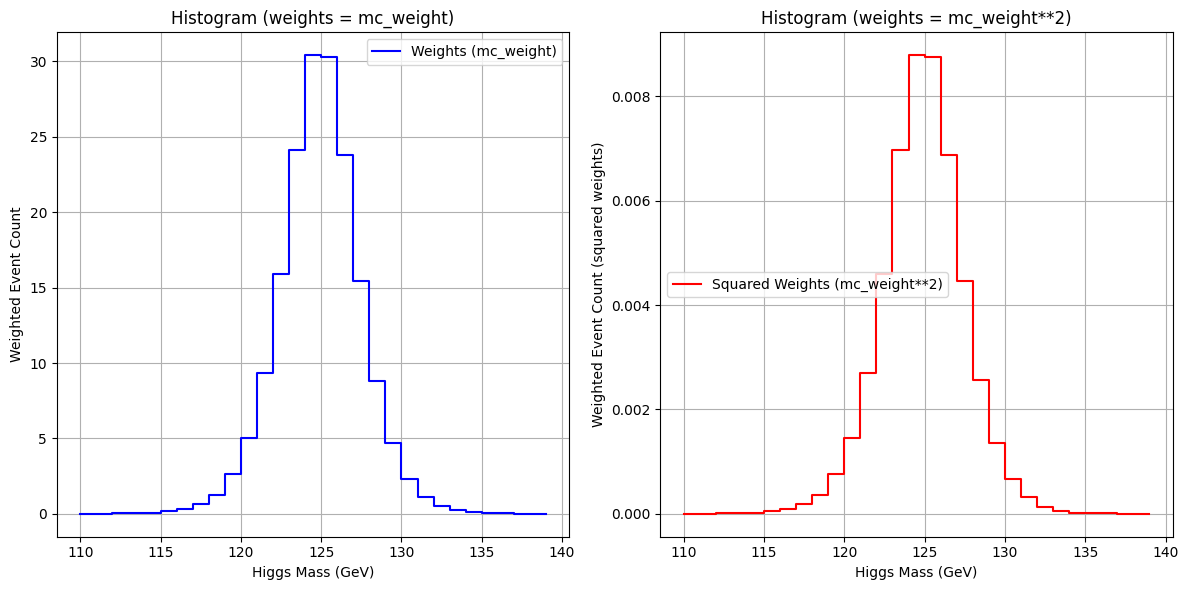

In [23]:
# Original weighted histogram (weights = mc_weight)
nh, xe = np.histogram(mc_mass, weights=mc_weight, bins=30, range=(110,140))

# Histogram with squared weights (weights = mc_weight**2)
nh2, _ = np.histogram(mc_mass, weights=mc_weight**2, bins=30, range=(110,140))

# Plotting
plt.figure(figsize=(12,6))

# Histogram with original weights
plt.subplot(1, 2, 1)
plt.step(xe[:-1], nh, where='post', label='Weights (mc_weight)', color='blue')
plt.xlabel('Higgs Mass (GeV)')
plt.ylabel('Weighted Event Count')
plt.title('Histogram (weights = mc_weight)')
plt.grid(True)
plt.legend()

# Histogram with squared weights
plt.subplot(1, 2, 2)
plt.step(xe[:-1], nh2, where='post', label='Squared Weights (mc_weight**2)', color='red')
plt.xlabel('Higgs Mass (GeV)')
plt.ylabel('Weighted Event Count (squared weights)')
plt.title('Histogram (weights = mc_weight**2)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
sig_pars = mi.values.to_dict()
sig_pars

{'mu': 125.02861132261748,
 'f': 0.7693928604749485,
 'sg1': 2.604349289570317,
 'sg2': 1.3434429864094755,
 'b': 1.294929230857228,
 'm': 3.0}

In [25]:

hrange = (100, 160)

def polCDF(x, b0, b1, b2, b3, b4):
    beta = [b0, b1, b2, b3, b4]
    bkgd = bernstein.integral(x, beta, hrange[0], hrange[1])
    bkgn = np.diff( bernstein.integral(hrange, beta, hrange[0], hrange[1]) )
    return bkgd / bkgn

def totalCDF(x, b0, b1, b2, b3, b4, Nb, mu):
    bkg = Nb * polCDF(x, b0, b1, b2, b3, b4)
    sig = mu * smSigExp * cbgCDF(x, **sig_pars)
    return bkg+sig

In [26]:
# The previous fit was mainly for the signal model, using the Crystal Ball and Gaussian combination
# to fit the Higgs signal shape and determine its central value, width, and tail parameters.
# Now we build a total model that is the sum of "background + signal".
# The background is modeled by a 4th-order Bernstein polynomial CDF scaled by the total background count;
# the signal is the previously determined signal shape (cbgCDF) multiplied by the expected signal count and the signal strength parameter μ.
# In this first step, μ is fixed to 0 to fit only the background for stable background parameters before introducing the signal.

dset = df['diphoton_mass'][:,0].values.astype(np.float64)
nh, xe = np.histogram(dset, bins=55, range=hrange)
n2ll = cost.ExtendedBinnedNLL(nh, xe, totalCDF)

mi = Minuit(n2ll, b0=1, b1=0.5, b2=0.3, b3=0.2, b4=0.1, Nb=len(dset), mu=0)
mi.limits["b0","b1","b2","b3","b4"] = (0,None)

# Fit the background only first
mi.fixed["mu"] = True
mi.limits["b0","b1","b2","b3","b4"] = (0,1)
mi.migrad()
mi.hesse()
mi.migrad() # call a second time to help convergence

# save the n2ll at the minimum
bkgo_n2ll = mi.fval

# save the background only fit par values
bkgo_pars = mi.values.to_dict()

mi # display the fit result

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 58.4 (χ²/ndof = 1.2)       │              Nfcn = 310              │
│ EDM = 7.42e-09 (Goal: 0.0002)    │            time = 0.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ b0   │   0.43    │   0.17    │            │            │    0    │    1    │       │
│ 1 │ b1   │   0.22    │   0.10    │            │            │    0    │    1    │       │
│ 2 │ b2   │   0.27    │   0.12    │            │            │    0    │    1    │       │
│ 3 │ b3   │   0.12    │   0.06    │            │            │    0    │    1    │       │
│ 4 │ b4   │   0.14    │   0.06    │            │            │    0    │    1    │       │
│ 5 │ Nb   │  9.66e3   │  0.10e3   │            │            │         │         │       │
│ 6 │ mu   │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬────────────────────────────────────────────────────────────────┐
│    │       b0       b1       b2       b3       b4       Nb       mu │
├────┼────────────────────────────────────────────────────────────────┤
│ b0 │    0.032    0.016    0.020   0.0088    0.011   -0.000    0.000 │
│ b1 │    0.016  0.00962    0.009   0.0053    0.005    0.005     0.00 │
│ b2 │    0.020    0.009   0.0142   0.0046    0.007   -0.006    0.000 │
│ b3 │   0.0088   0.0053   0.0046  0.00328   0.0028   0.0046   0.0000 │
│ b4 │    0.011    0.005    0.007   0.0028  0.00371   -0.001    0.000 │
│ Nb │   -0.000    0.005   -0.006   0.0046   -0.001 9.64e+03      0e3 │
│ mu │    0.000     0.00    0.000   0.0000    0.000      0e3        0 │
└────┴────────────────────────────────────────────────────────────────┘

In [27]:
bkgo_pars

{'b0': 0.4271460763256705,
 'b1': 0.21535284819790107,
 'b2': 0.2714286443850129,
 'b3': 0.11727668482087905,
 'b4': 0.14471244706268271,
 'Nb': 9664.00025275985,
 'mu': 0.0}

In [28]:
# Then fit the signal + background
# This section performs a combined fit of the signal and background models:
# 1. Release the fixed parameter μ so that it becomes free, and constrain its range to -5 to 5.
# 2. Call the minimization algorithms (migrad and hesse) multiple times to ensure convergence.
# 3. Save the N2LL at the minimum and the best fit parameters to evaluate the presence and strength of the signal.

# Release the fix on signal strength "mu"
mi.fixed["mu"] = False
mi.limits["mu"] = (-5,5)

# run minimisation
# needs a couple of attempts for convergence
mi.migrad()
mi.hesse()
mi.migrad()

# save n2ll at minimum
sb_n2ll = mi.fval

# save best fit parameter values
sb_pars = mi.values.to_dict()
mi

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 44.47 (χ²/ndof = 0.9)      │              Nfcn = 566              │
│ EDM = 2.22e-09 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ b0   │   0.44    │   0.18    │            │            │    0    │    1    │       │
│ 1 │ b1   │   0.22    │   0.10    │            │            │    0    │    1    │       │
│ 2 │ b2   │   0.22    │   0.10    │            │            │    0    │    1    │       │
│ 3 │ b3   │   0.16    │   0.07    │            │            │    0    │    1    │       │
│ 4 │ b4   │   0.14    │   0.06    │            │            │    0    │    1    │       │
│ 5 │ Nb   │  9.48e3   │  0.11e3   │            │            │         │         │       │
│ 6 │ mu   │   1.04    │   0.28    │            │            │   -5    │    5    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬────────────────────────────────────────────────────────────────┐
│    │       b0       b1       b2       b3       b4       Nb       mu │
├────┼────────────────────────────────────────────────────────────────┤
│ b0 │   0.0349    0.017    0.017    0.012    0.011   -0.125    0.001 │
│ b1 │    0.017   0.0104    0.007    0.007    0.006   -0.089    0.000 │
│ b2 │    0.017    0.007   0.0104    0.005    0.006    0.748   -0.004 │
│ b3 │    0.012    0.007    0.005  0.00534    0.004   -0.515    0.003 │
│ b4 │    0.011    0.006    0.006    0.004  0.00362    0.074   -0.000 │
│ Nb │   -0.125   -0.089    0.748   -0.515    0.074 1.18e+04   -13.22 │
│ mu │    0.001    0.000   -0.004    0.003   -0.000   -13.22   0.0807 │
└────┴────────────────────────────────────────────────────────────────┘

In [29]:
# get log-likelihood ratio
d2ll = bkgo_n2ll - sb_n2ll
signif = d2ll**0.5

print(f'-2\Delta ln L = {d2ll:4.2f}')
print(f'Wilks\' significance = {signif:4.2f}')


-2\Delta ln L = 13.93
Wilks' significance = 3.73


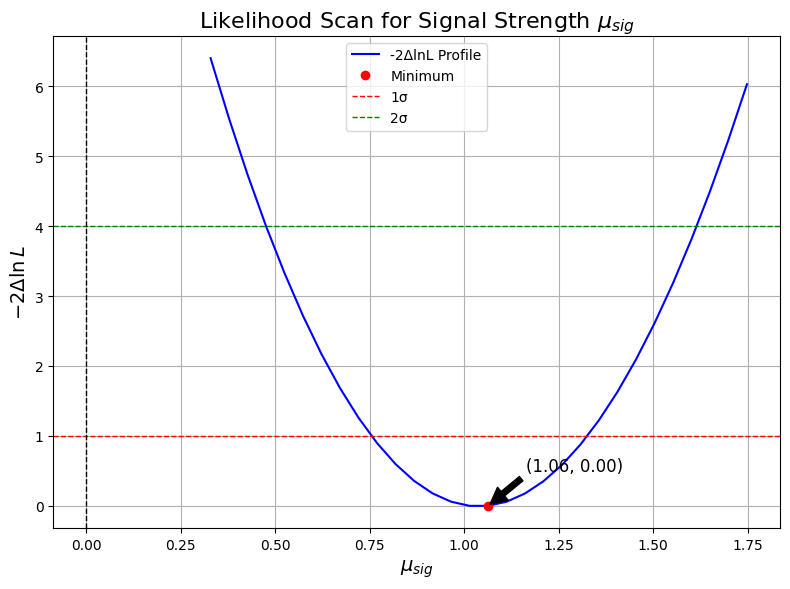

In [30]:


# Get the profile likelihood data for the parameter μ:
# x: μ values, y: corresponding -2ΔlnL, valid: boolean array of valid data points
x, y, valid = mi.mnprofile("mu", subtract_min=True, bound=2.5)

# Find the minimum point on the profile

x_valid = x[valid]
y_valid = y[valid]
min_index = np.argmin(y_valid)
x_min = x_valid[min_index]
y_min = y_valid[min_index]

# Create a figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the -2ΔlnL scan curve for μ (only valid points)
ax.plot(x_valid, y_valid, label='-2ΔlnL Profile', color='blue')

# Mark the minimum point with a red circle and annotate its coordinates
ax.plot(x_min, y_min, 'ro', label='Minimum')
ax.annotate(f'({x_min:.2f}, {y_min:.2f})', xy=(x_min, y_min), xytext=(x_min+0.1, y_min+0.5),
            arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12)

# Add horizontal reference lines:
# y=0 indicates the best-fit point,
# y=1 and y=4 correspond to the 1σ and 2σ confidence limits, respectively.
# ax.axhline(0, color='k', lw=1, label='Minimum')
ax.axhline(1, color='r', ls='--', lw=1, label='1σ')
ax.axhline(4, color='g', ls='--', lw=1, label='2σ')

# Add a vertical line at μ = 0
ax.axvline(0, color='k', ls='--', lw=1)

# Set axis labels and title
ax.set_xlabel('$\\mu_{sig}$', fontsize=14)
ax.set_ylabel('$-2\\Delta \\ln L$', fontsize=14)
ax.set_title('Likelihood Scan for Signal Strength $\\mu_{sig}$', fontsize=16)

# Display legend and grid
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()




In [31]:
# Compute the probability density functions (PDFs) for the signal and background:
# cbgPDF: Describes the Higgs signal mass distribution using a Gaussian + Crystal Ball combination.
# polPDF: Describes the background mass distribution using a 4th-order Bernstein polynomial.
# totalPDF: Computes the total mass distribution, which can include only background ('b'), only signal ('s'), or both.

def cbgPDF(x, mu, f, sg1, sg2, b, m):
    return f * norm.pdf(x, mu, sg1) + (1-f) * crystalball.pdf(x, b, m, mu, sg2) 

def polPDF(x, b0, b1, b2, b3, b4):
    beta = [b0, b1, b2, b3, b4]
    bkgd = bernstein.density(x, beta, hrange[0], hrange[1])
    bkgn = np.diff( bernstein.integral(hrange, beta, hrange[0], hrange[1]) )
    return bkgd / bkgn

def totalPDF(x, b0, b1, b2, b3, b4, Nb, mu, comps=['b','s']):
    bkg = Nb * polPDF(x, b0, b1, b2, b3, b4)
    sig = mu * smSigExp * cbgPDF(x, **sig_pars)
    res = np.zeros_like(x)
    if 'b' in comps:
        res += bkg
    if 's' in comps:
        res += sig
    return res


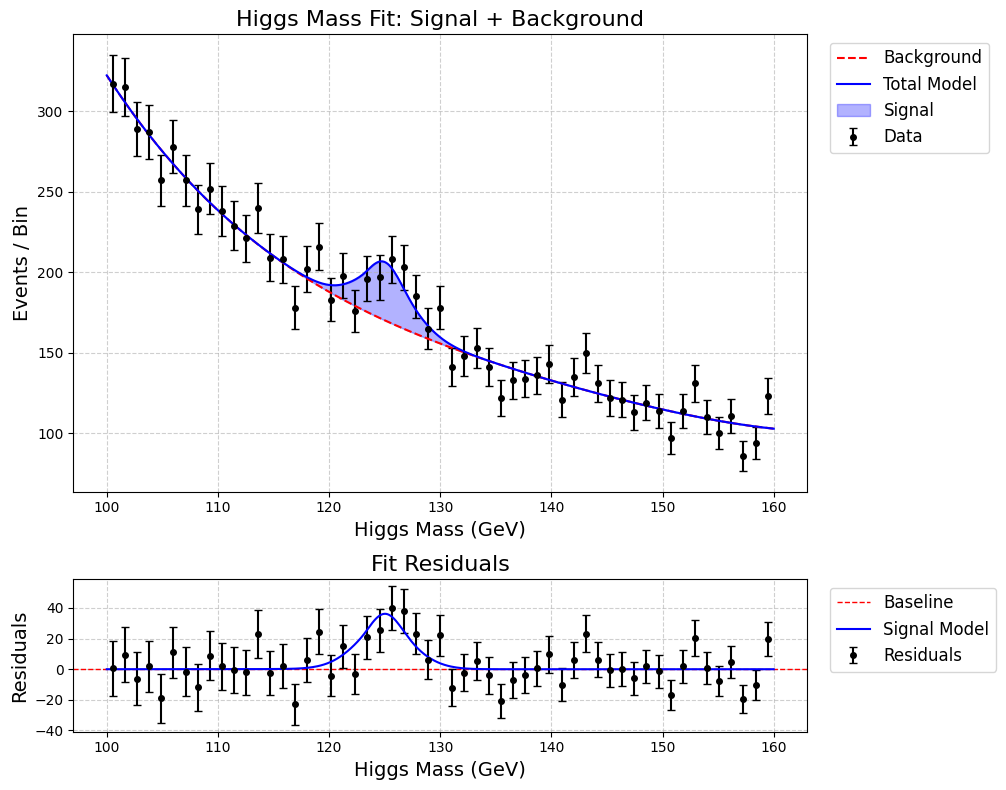

In [ ]:
# Compute the centers and bin width of the histogram
cx = 0.5 * (xe[1:] + xe[:-1])  
bw = xe[1] - xe[0]  

fig, ax = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': (3, 1)})

# In the first subplot, plot the experimental data with Poisson errors (sqrt(N))
ax[0].errorbar(cx, nh, nh**0.5, fmt='ko', label='Data', markersize=4, capsize=3)

# Compute the background, signal, and total model fit curves
x = np.linspace(*hrange, 400)  
yb = bw * totalPDF(x, **sb_pars, comps=['b'])  
ys = bw * totalPDF(x, **sb_pars, comps=['s'])  
yt = bw * totalPDF(x, **sb_pars)  

# Plot the background and total model curves
ax[0].plot(x, yb, 'r--', label='Background')  
ax[0].plot(x, yt, 'b-', label='Total Model')  
ax[0].fill_between(x, yb, yt, color='blue', alpha=0.3, label='Signal')  

ax[0].set_xlabel('Higgs Mass (GeV)', fontsize=14)
ax[0].set_ylabel('Events / Bin', fontsize=14)
ax[0].set_title('Higgs Mass Fit: Signal + Background', fontsize=16)
ax[0].grid(True, linestyle='--', alpha=0.6)
leg0 = ax[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=12)

# Compute residuals: Data - background fit
cb = bw * totalPDF(cx, **sb_pars, comps=['b'])  
dy = nh - cb  # Difference between data and background
dy_err = nh**0.5  # Poisson errors

# Plot the residuals in the second subplot
ax[1].axhline(0, color='r', linestyle='--', linewidth=1, label='Baseline')
ax[1].errorbar(cx, dy, dy_err, fmt='ko', markersize=4, capsize=3, label='Residuals')
ax[1].plot(x, yt - yb, 'b-', label='Signal Model')
ax[1].set_xlabel('Higgs Mass (GeV)', fontsize=14)
ax[1].set_ylabel('Residuals', fontsize=14)
ax[1].set_title('Fit Residuals', fontsize=16)
ax[1].grid(True, linestyle='--', alpha=0.6)
# Place the legend for the residual plot outside as well
leg1 = ax[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=12)

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Leave space on the right side
plt.show()


<!-- def pick_best_pair_for_event(subdf):
    """
    Input: subdf is a DataFrame containing all photon (subentry) rows for a given event (entry)
    Output: (best_i, best_j, best_mass)
         where best_i and best_j are the subentry indices of the optimal photon pair in the event,
         and best_mass is their invariant mass.
         If no valid combination exists, returns None.
    """
    
    # Extract the unique subentry indices for the event
    subentry_list = subdf.index.get_level_values("subentry").unique()

    # Use itertools.combinations to generate all pair combinations of subentries
    # Note: If the number of photons is large, there will be many combinations
    best_pair = None
    best_diff = float("inf")  # or 999999.

    for i, j in combinations(subentry_list, 2):
        # Retrieve the rows corresponding to subentries i and j (each row is a DataFrame)
        row_i = subdf.xs(i, level="subentry")
        row_j = subdf.xs(j, level="subentry")
        

        # Note: row_i["photon_pt"] is a Series of length 1,
        # so we need to extract the floating point value using .iloc[0] or .item()
        pt_i  = row_i["photon_pt"].iloc[0]
        eta_i = row_i["photon_eta"].iloc[0]
        phi_i = row_i["photon_phi"].iloc[0]
        e_i   = row_i["photon_e"].iloc[0]

        pt_j  = row_j["photon_pt"].iloc[0]
        eta_j = row_j["photon_eta"].iloc[0]
        phi_j = row_j["photon_phi"].iloc[0]
        e_j   = row_j["photon_e"].iloc[0]

        # Construct the 4-vectors (if the units are GeV, the mass will be in GeV)
        v1 = vector.obj(pt=pt_i, eta=eta_i, phi=phi_i, E=e_i)
        v2 = vector.obj(pt=pt_j, eta=eta_j, phi=phi_j, E=e_j)

        dipho_mass = (v1 + v2).m  # invariant mass

        # Calculate the difference from 125 GeV
        diff = abs(dipho_mass - 125.)
        if diff < best_diff:
            best_diff = diff
            best_pair = (i, j, dipho_mass)

    return best_pair  # # Returns (best_i, best_j, best_mass) or None -->